# Task 6: Customer Segmentation using K-Means Clustering

Segment mall customers based on demographic and shopping behavior using **K-Means clustering**.

### Workflow
1. Load and inspect customer data
2. Select clustering features
3. Standardize features
4. Use the Elbow Method to choose K
5. Train K-Means
6. Visualize clusters using 2D plots
7. Summarize customer segments


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

os.makedirs("outputs", exist_ok=True)


In [10]:
df = pd.read_csv("data/mall_customers.csv")
print("Shape:", df.shape)
display(df.head())
display(df.describe().round(2))


Shape: (550, 5)


,CustomerID,Age,AnnualIncome_k,PurchaseFrequency,SpendingScore
0,1,27,17.8,11.0,20.8
1,2,20,26.3,17.2,25.1
2,3,29,26.5,3.9,30.0
3,4,30,34.5,6.3,13.5
4,5,18,30.8,35.0,21.0


,CustomerID,Age,AnnualIncome_k,PurchaseFrequency,SpendingScore
count,550.00,550.00,550.00,550.00,550.00
mean,275.50,45.72,47.98,45.63,48.56
std,158.92,17.87,21.27,26.13,25.48
min,1.00,18.00,15.00,1.00,3.30
25%,138.25,28.00,28.42,20.72,24.95
50%,275.50,48.00,45.00,45.70,45.60
75%,412.75,64.00,68.68,71.40,74.30
max,550.00,70.00,90.50,100.00,100.00


In [11]:
features = ["Age", "AnnualIncome_k", "PurchaseFrequency", "SpendingScore"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


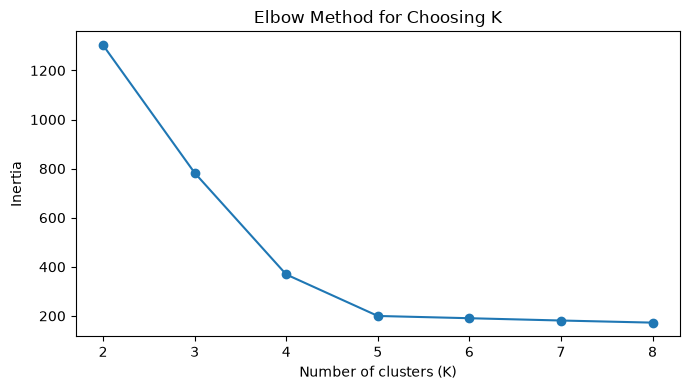

In [12]:
inertias = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("outputs/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, df["Cluster"])
print(f"Silhouette Score: {silhouette:.3f}")
display(df.groupby("Cluster")[features].mean().round(2))


Silhouette Score: 0.624


,Age,AnnualIncome_k,PurchaseFrequency,SpendingScore
Cluster,,,,
0,29.58,69.11,20.09,74.81
1,66.94,28.34,77.60,23.86
2,24.72,24.90,18.57,21.91
3,64.13,73.43,71.76,78.32
4,50.22,44.83,50.22,44.38


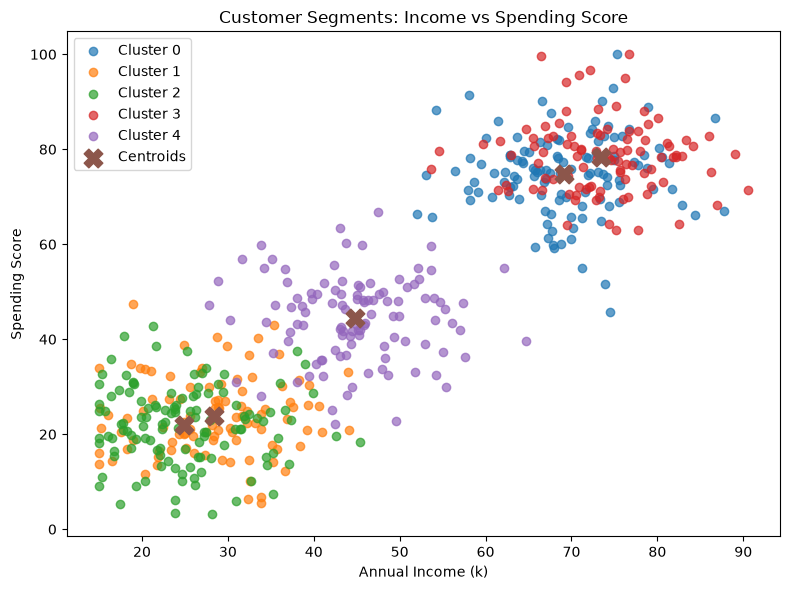

In [14]:
plt.figure(figsize=(8, 6))
for cluster in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cluster]
    plt.scatter(subset["AnnualIncome_k"], subset["SpendingScore"],
                label=f"Cluster {cluster}", alpha=0.7)

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 1], centers_original[:, 3],
            marker="X", s=180, label="Centroids")

plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.title("Customer Segments: Income vs Spending Score")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/income_vs_spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()


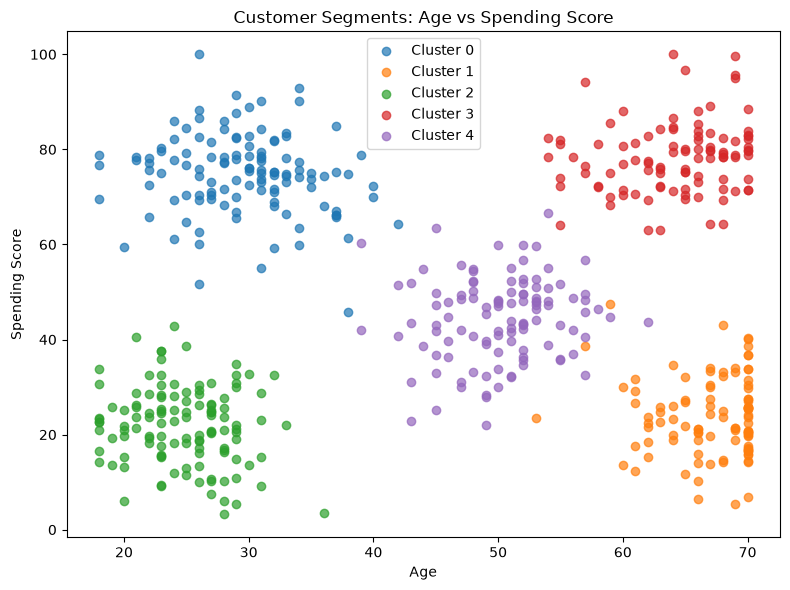

In [15]:
plt.figure(figsize=(8, 6))
for cluster in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cluster]
    plt.scatter(subset["Age"], subset["SpendingScore"],
                label=f"Cluster {cluster}", alpha=0.7)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Customer Segments: Age vs Spending Score")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/age_vs_spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
cluster_summary = df.groupby("Cluster")[features].mean().round(2)
cluster_summary.insert(0, "Customers", df["Cluster"].value_counts().sort_index())
display(cluster_summary)
cluster_summary.to_csv("outputs/cluster_summary.csv")


,Customers,Age,AnnualIncome_k,PurchaseFrequency,SpendingScore
Cluster,,,,,
0,120,29.58,69.11,20.09,74.81
1,100,66.94,28.34,77.60,23.86
2,120,24.72,24.90,18.57,21.91
3,100,64.13,73.43,71.76,78.32
4,110,50.22,44.83,50.22,44.38


## Conclusion

K-Means groups customers with similar demographic and shopping behavior. The Income vs Spending Score plot gives a clear 2D view of the segments, while Age vs Spending Score provides an additional behavioral perspective.
